In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import umap

from dpks import QuantMatrix
from dfmodel import DigitalFamilyBinary
from pandas.plotting import boxplot
from scanpy.experimental.pp import highly_variable_genes
from torch.ao.nn.quantized.functional import threshold


In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [4]:
proteomics_data_train = pd.read_csv(
    "../1_proteomics_data/protein_train_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

proteomics_data_val = pd.read_csv(
    "../1_proteomics_data/protein_val_filtered.tsv"
    , sep="\t"
)
clinical_data_val = pd.read_csv(
    "../0_clinical_data/design_matrix_validation.tsv",
    sep='\t'
)
clinical_data_val['sample'] = clinical_data_val['injection']
clinical_data_val = clinical_data_val[clinical_data_val['injection'].isin(proteomics_data_val.columns)].copy().reset_index()


proteomics_data_test = pd.read_csv(
    "../1_proteomics_data/protein_test_filtered.tsv"
    , sep="\t"
)
clinical_data_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)
clinical_data_test['sample'] = clinical_data_test['injection']
#clinical_data_test = clinical_data_test[clinical_data_test['injection'].isin(proteomics_data_test.columns)].copy().reset_index()



In [5]:
clinical_data_test

,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,...,albumin_0_24h,albumin_24_48h,albumin_0_48h,albumin_48_72h,albumin_0_72h,urinary_tract_infection,abdominal_infection,skin_and_soft_tissue_infection,pneumonia,sample
0,SA_BOX_9-159_S1-D9_1_6172,85.0,28.0,86.0,146.0,95.333333,1.0,39.1,102.0,6.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_9-159_S1-D9_1_6172
1,SA_BOX_7-267_S4-H8_1_5971,94.0,22.0,159.0,90.0,70.000000,1.0,37.7,145.0,12.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_7-267_S4-H8_1_5971
2,SA_BOX_15-464_S4-G9_1_6763,82.0,36.0,125.0,160.0,NaN,1.0,38.7,72.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_15-464_S4-G9_1_6763
3,SA_BOX_2-1700_S2-D11_1_6971,92.0,16.0,100.0,100.0,NaN,1.0,38.8,216.0,35.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,SA_BOX_2-1700_S2-D11_1_6971
4,SA_BOX_7-1728_S4-F9_1_5977,82.0,30.0,107.0,120.0,NaN,1.0,38.8,166.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_7-1728_S4-F9_1_5977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,SA_BOX_6-659_S2-F10_1_5887,86.0,28.0,91.0,85.0,67.000000,1.0,38.8,145.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_6-659_S2-F10_1_5887
676,SA_BOX_7-2061_S4-H5_1_5946,96.0,24.0,134.0,107.0,95.666667,1.0,38.8,58.0,17.0,...,200.0,0.0,200.0,0.0,200.0,0.0,0.0,0.0,0.0,SA_BOX_7-2061_S4-H5_1_5946
677,SA_BOX_2-764_S2-G2_1_6901,90.0,32.0,60.0,100.0,73.333333,1.0,38.6,141.0,18.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_2-764_S2-G2_1_6901
678,SA_BOX_6-774_S2-D10_1_5885,99.0,28.0,120.0,100.0,NaN,1.0,38.0,94.0,13.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_6-774_S2-D10_1_5885


In [6]:
clinical_data_train = pd.concat(
    [clinical_data_train,
     clinical_data_test,
     #clinical_data_val,
     #clinical_data_hero
     ],
    ignore_index=True
)

# proteomics_data_train
proteomics_data_train = proteomics_data_train.set_index("Protein").join(
    proteomics_data_test.set_index("Protein")
).reset_index()

# proteomics_data_train = proteomics_data_train.set_index("Protein").join(
#     proteomics_data_hero.set_index("Protein")
# ).reset_index()

In [7]:
clinical_data_train

,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,...,albumin_0_24h,albumin_24_48h,albumin_0_48h,albumin_48_72h,albumin_0_72h,urinary_tract_infection,abdominal_infection,skin_and_soft_tissue_infection,pneumonia,sample
0,SA_BOX_1-462_S1-C8_1_6848,85.0,24.0,120.0,120.0,95.333333,1.0,39.5,73.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,SA_BOX_1-462_S1-C8_1_6848
1,SA_BOX_9-2606_S1-A5_1_6136,75.0,30.0,117.0,134.0,107.333333,1.0,37.3,121.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_9-2606_S1-A5_1_6136
2,SA_BOX_3-2442_S4-H8_1_5579,94.0,48.0,125.0,120.0,NaN,1.0,39.9,66.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_3-2442_S4-H8_1_5579
3,SA_BOX_2-1644_S2-A10_1_6960,80.0,35.0,94.0,113.0,75.666667,1.0,38.6,122.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_2-1644_S2-A10_1_6960
4,SA_BOX_4-2435_S5-E11_1_5698,87.0,18.0,75.0,136.0,121.333333,1.0,35.6,107.0,6.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_4-2435_S5-E11_1_5698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1355,SA_BOX_6-659_S2-F10_1_5887,86.0,28.0,91.0,85.0,67.000000,1.0,38.8,145.0,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_6-659_S2-F10_1_5887
1356,SA_BOX_7-2061_S4-H5_1_5946,96.0,24.0,134.0,107.0,95.666667,1.0,38.8,58.0,17.0,...,200.0,0.0,200.0,0.0,200.0,0.0,0.0,0.0,0.0,SA_BOX_7-2061_S4-H5_1_5946
1357,SA_BOX_2-764_S2-G2_1_6901,90.0,32.0,60.0,100.0,73.333333,1.0,38.6,141.0,18.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_2-764_S2-G2_1_6901
1358,SA_BOX_6-774_S2-D10_1_5885,99.0,28.0,120.0,100.0,NaN,1.0,38.0,94.0,13.0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,SA_BOX_6-774_S2-D10_1_5885


In [8]:

clinical_data_test = pd.concat(
    [
        clinical_data_val,
     ],
    ignore_index=True
)

proteomics_data_test = proteomics_data_val.copy()

In [9]:
sum_ = 0
infection_columns = []
for col in clinical_data_train.columns:

    if col.endswith("_culture"):
        counts = clinical_data_train[col].value_counts()
        sum_ += counts.get(1, 0)

        if counts.get(1, 0) > 1:
            print(col, counts.get(1, 0))

k_pneu_blood_culture 44
enterobact_blood_culture 25
e_coli_blood_culture 219
pseud_blood_culture 10
s_aureus_blood_culture 61
strep_pneumoniae_blood_culture 27
gas_blood_culture 18
gbs_blood_culture 7
gcs_blood_culture 9
ggs_blood_culture 15
faecalis_blood_culture 27
faecium_blood_culture 10


In [10]:
streptocci = [
    "strep_pneumoniae_blood_culture",
    "gas_blood_culture",
    "gbs_blood_culture",
    "gcs_blood_culture",
    "ggs_blood_culture",
]

staph = ["s_aureus_blood_culture",]

e_coli = [
    "e_coli_blood_culture",
]

kpneu = ["k_pneu_blood_culture",]

pseud = ["pseud_blood_culture",]

enterob = ["enterobact_blood_culture"]

enteroc = [
    "faecalis_blood_culture",
    "faecium_blood_culture"
]

In [11]:
gram_negative = [
    "k_pneu_blood_culture",
    "enterobact_blood_culture",
    #"other_g_neg_blood_culture",
    "e_coli_blood_culture",
    "pseud_blood_culture"
]

In [12]:
gram_positive = [
    "s_aureus_blood_culture",
    "strep_pneumoniae_blood_culture",
    "gas_blood_culture",
    "gbs_blood_culture",
    "gcs_blood_culture",
    "ggs_blood_culture",
    "faecalis_blood_culture",
    "faecium_blood_culture",
    #"other_g_positive_blood_culture"
]

In [13]:
clinical_data_train['gram_positive'] = np.where(
    clinical_data_train[gram_positive].sum(axis=1) > 0, 1, 0
)

clinical_data_train['gram_negative'] = np.where(
    clinical_data_train[gram_negative].sum(axis=1) > 0, 1, 0
)

clinical_data_train['strep'] = np.where(
    clinical_data_train[streptocci].sum(axis=1) > 0, 1, 0
)


In [14]:
clinical_data_train['both_gram'] = clinical_data_train[['gram_negative', 'gram_positive']].sum(axis=1).values

In [15]:
clinical_data_train['both_gram'].value_counts()

both_gram
0    927
1    416
2     17
Name: count, dtype: int64

In [16]:
clinical_data_test['blood_culture_positive'].value_counts()

blood_culture_positive
0.0    212
1.0     41
Name: count, dtype: int64

In [17]:
#clinical_data_train = clinical_data_train[clinical_data_train['both_gram'].isin([0, 1])].reset_index().copy()

In [18]:
#clinical_data_train[(clinical_data_train['both_gram'] == 2)][gram_positive + gram_negative]

In [19]:
clinical_data_train['bacteremia'] =  np.where(
    (clinical_data_train['blood_culture_positive'] == 1) & (clinical_data_train['irrelevante_bacteremia'] == 0)
    , 1, 0
)

clinical_data_train['uti'] = np.where(
    (clinical_data_train['urinary_tract_infection'] == 1) & (clinical_data_train['abdominal_infection'] == 0) & (clinical_data_train['skin_and_soft_tissue_infection'] == 0) & (clinical_data_train['pneumonia'] == 0)
    , 1, 0
)

clinical_data_train['abdominal'] = np.where(
    (clinical_data_train['urinary_tract_infection'] == 0) & (clinical_data_train['abdominal_infection'] == 1) & (clinical_data_train['skin_and_soft_tissue_infection'] == 0) & (clinical_data_train['pneumonia'] == 0)
    , 1, 0
)

clinical_data_train['sst'] = np.where(
    (clinical_data_train['urinary_tract_infection'] == 0) & (clinical_data_train['abdominal_infection'] == 0) & (clinical_data_train['skin_and_soft_tissue_infection'] == 1) & (clinical_data_train['pneumonia'] == 0)
    , 1, 0
)

clinical_data_train['lower_resp'] = np.where(
    (clinical_data_train['urinary_tract_infection'] == 0) & (clinical_data_train['abdominal_infection'] == 0) & (clinical_data_train['skin_and_soft_tissue_infection'] == 0) & (clinical_data_train['pneumonia'] == 1)
    , 1, 0
)

clinical_data_train['ecoli'] = np.where(
    clinical_data_train["e_coli_blood_culture"] == 1, 1, 0
)

clinical_data_train['strep'] = np.where(
    clinical_data_train[streptocci].sum(axis=1) > 0, 1, 0
)

clinical_data_train['staph'] = np.where(
    clinical_data_train[staph].sum(axis=1) > 0, 1, 0
)

clinical_data_train['kpneu'] = np.where(
    clinical_data_train[kpneu].sum(axis=1) > 0, 1, 0
)

clinical_data_train['pseud'] = np.where(
    clinical_data_train[pseud].sum(axis=1) > 0, 1, 0
)

clinical_data_train['enteroc'] = np.where(
    clinical_data_train[enteroc].sum(axis=1) > 0, 1, 0
)

clinical_data_train['strep_a'] = np.where(
    clinical_data_train["gas_blood_culture"] > 0, 1, 0
)

In [20]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)
quant_matrix_test = preprocess_data(proteomics_data_test, design_matrix=clinical_data_test)

In [21]:
X, y = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))
X_test, y_test = quant_matrix_test.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))

In [22]:
from sklearn.feature_selection import SelectFdr, f_classif

fdr = SelectFdr(f_classif, alpha=0.1)
fdr.fit(X, clinical_data_train['verified_infection'])

protein_columns = fdr.get_feature_names_out()

In [23]:
protein_columns

array(['FIBA_HUMAN', 'TRFE_HUMAN', 'VWF_HUMAN', 'FINC_HUMAN',
       'FIBG_HUMAN', 'HPT_HUMAN', 'HRG_HUMAN', 'APOA1_HUMAN',
       'KLKB1_HUMAN', 'AFAM_HUMAN', 'ITIH2_HUMAN', 'ANT3_HUMAN',
       'FIBB_HUMAN', 'CBPN_HUMAN', 'BTD_HUMAN', 'A2GL_HUMAN',
       'HGFA_HUMAN', 'APOB_HUMAN', 'A1AT_HUMAN', 'PROC_HUMAN',
       'ITIH1_HUMAN', 'FETUA_HUMAN', 'HEP2_HUMAN', 'APOH_HUMAN',
       'VCAM1_HUMAN', 'CBPB2_HUMAN', 'CLUS_HUMAN', 'CD14_HUMAN',
       'C163A_HUMAN', 'PCSK9_HUMAN', 'CFAB_HUMAN', 'FETUB_HUMAN',
       'RARR2_HUMAN', 'CRP_HUMAN', 'FGL1_HUMAN', 'PLMN_HUMAN',
       'APOD_HUMAN', 'MASP1_HUMAN', 'H4_HUMAN', 'SPP24_HUMAN',
       'CAMP_HUMAN', 'APOA2_HUMAN', 'LBP_HUMAN', 'APOC2_HUMAN',
       'FBLN5_HUMAN', 'TIMP1_HUMAN', 'ZPI_HUMAN', 'THBG_HUMAN',
       'SEPP1_HUMAN', 'APOM_HUMAN', 'PHLD_HUMAN', 'SAA1_HUMAN',
       'OAF_HUMAN', 'RET4_HUMAN', 'SAA2_HUMAN', 'CRIS3_HUMAN',
       'ICAM1_HUMAN', 'FCN2_HUMAN', 'IPSP_HUMAN', 'ANGI_HUMAN',
       'CHLE_HUMAN', 'CATB_HUMAN', 'CATD_HUMA

In [24]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X_test[protein_columns] = protein_scaler.transform(X_test[protein_columns])

In [25]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis

bact_neighborhood = NeighborhoodComponentsAnalysis(
    n_components=1,
)
bact_components = bact_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["bacteremia"])

gram_pos_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
gram_pos_components = gram_pos_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["gram_positive"])

gram_neg_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
gram_neg_components = gram_neg_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["gram_negative"])

uti_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
uti_components = uti_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["uti"])

abdominal_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
abdominal_components = abdominal_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["abdominal"])

sst_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
sst_components = sst_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["sst"])

lower_resp_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
lower_resp_components = lower_resp_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["lower_resp"])

infection_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
infection_components = infection_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["verified_infection"])
#
ecoli_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
ecoli_components = ecoli_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["ecoli"])

strep_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
strep_components = strep_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["strep"])

staph_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
staph_components = staph_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["staph"])

kpneu_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
kpneu_components = kpneu_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["kpneu"])

pseud_neighborhood = NeighborhoodComponentsAnalysis(n_components=1)
pseud_components = pseud_neighborhood.fit_transform(X[protein_columns], y=clinical_data_train["pseud"])

In [26]:
bact_components_test = bact_neighborhood.transform(X_test[protein_columns])
gram_pos_components_test = gram_pos_neighborhood.transform(X_test[protein_columns])
gram_neg_components_test = gram_neg_neighborhood.transform(X_test[protein_columns])
uti_components_test = uti_neighborhood.transform(X_test[protein_columns])
abdominal_components_test = abdominal_neighborhood.transform(X_test[protein_columns])
sst_components_test = sst_neighborhood.transform(X_test[protein_columns])
lower_resp_components_test = lower_resp_neighborhood.transform(X_test[protein_columns])
infection_components_test = infection_neighborhood.transform(X_test[protein_columns])
ecoli_components_test = ecoli_neighborhood.transform(X_test[protein_columns])
strep_components_test = strep_neighborhood.transform(X_test[protein_columns])
staph_components_test = staph_neighborhood.transform(X_test[protein_columns])
kpneu_components_test = kpneu_neighborhood.transform(X_test[protein_columns])
pseud_components_test = pseud_neighborhood.transform(X_test[protein_columns])

In [27]:
component_normalizer = StandardScaler()

bact_components = pd.DataFrame(
    bact_components,
    columns=["bacteremia_1",]
)

gram_pos_components = pd.DataFrame(
    gram_pos_components,
    columns=["gram_positive_1",]
)

gram_neg_components = pd.DataFrame(
    gram_neg_components,
    columns=["gram_negative_1",]
)

uti_components = pd.DataFrame(
    uti_components,
    columns=["uti1",]
)
abdominal_components = pd.DataFrame(
    abdominal_components,
    columns=["ab1",]
)
sst_components = pd.DataFrame(
    sst_components,
    columns=["sst1", ]
)
lower_resp_components = pd.DataFrame(
    lower_resp_components,
    columns=["lr1",]
)

infection_components = pd.DataFrame(
    infection_components,
    columns=["infc1",]
)

ecoli_components = pd.DataFrame(
    ecoli_components,
    columns=["ecoli1", ]
)

strep_components = pd.DataFrame(
    strep_components,
    columns=["strep1", ]
)

staph_components = pd.DataFrame(
    staph_components,
    columns=["staph1", ]
)

kpneu_components = pd.DataFrame(
    kpneu_components,
    columns=["kpneu1", ]
)

pseud_components = pd.DataFrame(
    pseud_components,
    columns=["pseud1", ]
)

components = pd.concat(
    [
        bact_components,
        gram_pos_components,
        gram_neg_components,
        infection_components,
        uti_components,
        abdominal_components,
        sst_components,
        lower_resp_components,
    ],
    axis=1
)


component_cols = components.columns

In [28]:
components[component_cols] = component_normalizer.fit_transform(components[component_cols])

In [29]:
clinical_data_train[component_cols] = components[component_cols]

In [30]:
combined_columns = component_cols
combined_columns

Index(['bacteremia_1', 'gram_positive_1', 'gram_negative_1', 'infc1', 'uti1',
       'ab1', 'sst1', 'lr1'],
      dtype='object')

In [31]:
bact_components_test = pd.DataFrame(
    bact_components_test,
    columns=["bacteremia_1",]
)

gram_pos_components_test = pd.DataFrame(
    gram_pos_components_test,
    columns=["gram_positive_1",]
)

gram_neg_components_test = pd.DataFrame(
    gram_neg_components_test,
    columns=["gram_negative_1",]
)

uti_components_test = pd.DataFrame(
    uti_components_test,
    columns=["uti1",]
)
abdominal_components_test = pd.DataFrame(
    abdominal_components_test,
    columns=["ab1",]
)
sst_components_test = pd.DataFrame(
    sst_components_test,
    columns=["sst1", ]
)
lower_resp_components_test = pd.DataFrame(
    lower_resp_components_test,
    columns=["lr1",]
)

infection_components_test = pd.DataFrame(
    infection_components_test,
    columns=["infc1",]
)
#
# ecoli_components_test = pd.DataFrame(
#     ecoli_components_test,
#     columns=["ecoli1", ]
# )
#
# strep_components_test = pd.DataFrame(
#     strep_components_test,
#     columns=["strep1", ]
# )
#
# staph_components_test = pd.DataFrame(
#     staph_components_test,
#     columns=["staph1", ]
# )
#
# kpneu_components_test = pd.DataFrame(
#     kpneu_components_test,
#     columns=["kpneu1", ]
# )
#
# pseud_components_test = pd.DataFrame(
#     pseud_components_test,
#     columns=["pseud1", ]
# )

components_test = pd.concat(
    [
        bact_components_test,
        gram_pos_components_test,
        gram_neg_components_test,
        infection_components_test,
        uti_components_test,
        abdominal_components_test,
        sst_components_test,
        lower_resp_components_test,
    ],
    axis=1
)

component_cols = components.columns

In [32]:
components_test[component_cols] = component_normalizer.transform(components_test[component_cols])

In [33]:
clinical_data_test[component_cols] = components_test[component_cols]

In [34]:
df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000
)

In [35]:
df_estimator.fit(clinical_data_train, features=combined_columns)

In [36]:
clinical_data_train['Bacteremia Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="bacteremia", bootstrap=True)
clinical_data_train['Infection Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="verified_infection", bootstrap=True)

clinical_data_train['Lower Resp Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="lower_resp", bootstrap=True)
clinical_data_train['Gram Pos Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="gram_positive", bootstrap=True)
clinical_data_train['Gram Neg Rate'] = df_estimator.predict(clinical_data_train, features=combined_columns, target_column="gram_negative", bootstrap=True)

In [37]:
display_columns = [
    "Infection Rate",
    "Bacteremia Rate",
    "Gram Pos Rate",
    "Gram Neg Rate",
]

In [38]:
len(display_columns)

4

In [39]:
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [40]:
from joblib import dump

with open("graph_positions_bacteria", "wb") as f:

    dump(positions, f)

In [41]:
display_columns

['Infection Rate', 'Bacteremia Rate', 'Gram Pos Rate', 'Gram Neg Rate']

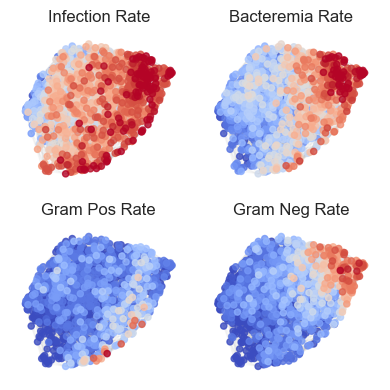

In [42]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    #gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 1,]}
)

axs = axs.ravel()

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(clinical_data_train[[col]])

    color_map = dict(zip(clinical_data_train.index, values))
    ordered_nodes = list(clinical_data_train.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=20, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)


fig.set_size_inches((4, 4))
plt.tight_layout()

fig.savefig(
    "infection_maps_bacteria.pdf", dpi=300, bbox_inches="tight", transparent=True
)

<Axes: xlabel='Gram Pos Rate', ylabel='Count'>

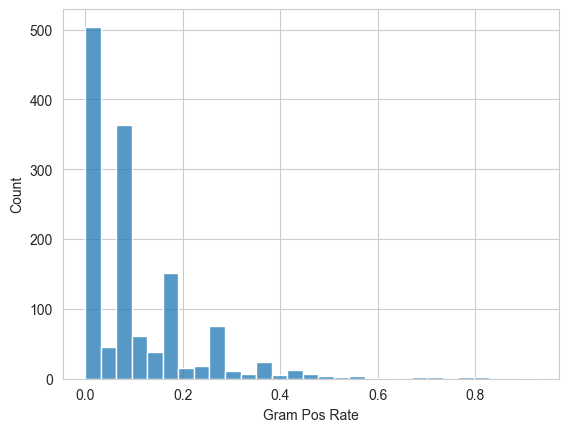

In [43]:
sns.histplot(
    data=clinical_data_train,
    x="Gram Pos Rate",
)

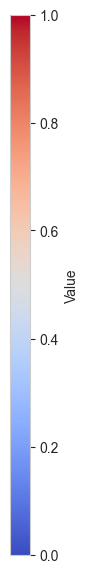

In [44]:

sm = plt.cm.ScalarMappable(cmap="coolwarm")

# Plot only the color bar
fig = plt.figure(figsize=(1, 6))

ax = fig.add_axes([0.3, 0.05, 0.2, 0.9])  # position only the colorbar # position only the colorbar
cb = fig.colorbar(sm, cax=ax, orientation='vertical')
cb.set_label('Value')

fig.savefig("colorbar.pdf", bbox_inches="tight")

In [45]:
clinical_data_test['bacteremia'] =  np.where(
    (clinical_data_test['blood_culture_positive'] == 1)
    , 1, 0
)

clinical_data_test['uti'] = np.where(
    (clinical_data_test['urinary_tract_infection'] == 1) & (clinical_data_test['abdominal_infection'] == 0) & (clinical_data_test['skin_and_soft_tissue_infection'] == 0) & (clinical_data_test['pneumonia'] == 0)
    , 1, 0
)

clinical_data_test['abdominal'] = np.where(
    (clinical_data_test['urinary_tract_infection'] == 0) & (clinical_data_test['abdominal_infection'] == 1) & (clinical_data_test['skin_and_soft_tissue_infection'] == 0) & (clinical_data_test['pneumonia'] == 0)
    , 1, 0
)

clinical_data_test['sst'] = np.where(
    (clinical_data_test['urinary_tract_infection'] == 0) & (clinical_data_test['abdominal_infection'] == 0) & (clinical_data_test['skin_and_soft_tissue_infection'] == 1) & (clinical_data_test['pneumonia'] == 0)
    , 1, 0
)

clinical_data_test['lower_resp'] = np.where(
    (clinical_data_test['urinary_tract_infection'] == 0) & (clinical_data_test['abdominal_infection'] == 0) & (clinical_data_test['skin_and_soft_tissue_infection'] == 0) & (clinical_data_test['pneumonia'] == 1)
    , 1, 0
)

clinical_data_test['ecoli'] = np.where(
    clinical_data_test["e_coli_blood_culture"] == 1, 1, 0
)

clinical_data_test['gram_positive'] = np.where(
    clinical_data_test[gram_positive].sum(axis=1) > 0, 1, 0
)

clinical_data_test['gram_negative'] = np.where(
    clinical_data_test[gram_negative].sum(axis=1) > 0, 1, 0
)

clinical_data_test['strep'] = np.where(
    clinical_data_test[streptocci].sum(axis=1) > 0, 1, 0
)

clinical_data_test['enteroc'] = np.where(
    clinical_data_test[enteroc].sum(axis=1) > 0, 1, 0
)

In [46]:
clinical_data_test['Bacteremia Rate'] = df_estimator.predict(clinical_data_test, features=combined_columns, target_column="bacteremia", bootstrap=True)
bacteremia_bootstrap_df = df_estimator.bootstrap_results_df.copy()

clinical_data_test['Infection Rate'] = df_estimator.predict(clinical_data_test, features=combined_columns, target_column="verified_infection", bootstrap=True)
infection_bootstrap_df = df_estimator.bootstrap_results_df.copy()

clinical_data_test['Lower Resp Rate'] = df_estimator.predict(clinical_data_test, features=combined_columns, target_column="lower_resp", bootstrap=True)
lower_resp_boostrap_df = df_estimator.bootstrap_results_df.copy()

clinical_data_test['Gram Pos Rate'] = df_estimator.predict(clinical_data_test, features=combined_columns, target_column="gram_positive", bootstrap=True)
gram_pos_bootstrap_df = df_estimator.bootstrap_results_df.copy()

clinical_data_test['Gram Neg Rate'] = df_estimator.predict(clinical_data_test, features=combined_columns, target_column="gram_negative", bootstrap=True)
gram_neg_bootstrap_df = df_estimator.bootstrap_results_df.copy()

In [47]:
gram_pos_bootstrap_df.join(
    clinical_data_test
).to_csv(
    "gp_bootstrap_results_df.csv",
)

infection_bootstrap_df.join(
    clinical_data_test
).to_csv(
    "infection_bootstrap_results_df.csv",
)

gram_neg_bootstrap_df.join(
    clinical_data_test
).to_csv(
    "gn_bootstrap_results_df.csv",
)

lower_resp_boostrap_df.join(
    clinical_data_test
).to_csv(
    "lower_resp_bootstrap_results_df.csv",
)

bacteremia_bootstrap_df.join(
    clinical_data_test
).to_csv(
    "bacteremia_bootstrap_results_df.csv",
)

In [48]:
clinical_data_test.to_csv(
    "design_matrix_pathogen_test.tsv",
    sep="\t",
    index=False,
)

clinical_data_train.to_csv(
    "design_matrix_pathogen_train.tsv",
    sep="\t",
    index=False,
)

In [49]:
display_columns = [
    "Lower Resp Rate",
]

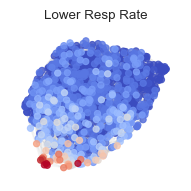

In [50]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1)


from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    #gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 1,]}
)

#axs = axs.ravel()

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(clinical_data_train[[col]])

    color_map = dict(zip(clinical_data_train.index, values))
    ordered_nodes = list(clinical_data_train.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=20, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs)
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs)

    axs.axis("off")

    axs.set_title(col)


#fig.set_size_inches((8.26 / 4, 2.5))
fig.set_size_inches(2, 2)
plt.tight_layout()

fig.savefig(
    "infection_maps_localization.pdf", dpi=300, bbox_inches="tight", transparent=True
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: t-test independent samples, P_val:3.110e-10 t=-6.557e+00


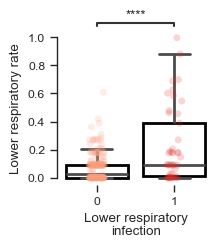

In [51]:
from statannotations.Annotator import Annotator
from scipy.stats import ttest_ind

fig, ax = plt.subplots()

sns.stripplot(
    data=clinical_data_test,
    y="Lower Resp Rate",
    x="lower_resp",
    hue="lower_resp",
    ax=ax,
    palette="Reds",
    linewidth=0,
    legend=False,
    alpha=0.2,

)

sns.boxplot(
    data=clinical_data_test,
    y="Lower Resp Rate",
    x="lower_resp",
    hue="lower_resp",
    ax=ax,
    #palette="Blues",
    linewidth=2,
    legend=False,
    showfliers=False,
    boxprops={'facecolor':'none', 'edgecolor':'black'}
)

sns.despine(ax=ax, bottom=True, top=True, trim=True, offset=1)

pairs = [(0, 1)]

annot = Annotator(ax, pairs, data=clinical_data_test, x="lower_resp", y="Lower Resp Rate")
annot.configure(test="t-test_ind", text_format="star", loc="outside", verbose=3)
annot.apply_test()
ax, test_results = annot.annotate()

fig.set_size_inches(2, 2)

ax.set_xlabel("Lower respiratory\ninfection")
ax.set_ylabel("Lower respiratory rate")

fig.savefig(
    "lower_resp_test.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
)